# Question:
### Is there a correlation between gender and reaction time?

## Analysis:
### observational; not all students in the USA

In [1]:
import pandas as pd
import seaborn
import matplotlib
import numpy
from statsmodels.graphics.mosaicplot import mosaic

In [11]:
teenagers = pd.read_csv("CensusAtSchool.csv")

In [12]:
t2 = teenagers.copy()
t2_r = t2["Reaction_time"]
t2_r2 = t2_r.copy()
t2_r = pd.to_numeric(t2_r, errors="coerce")
t2_g = t2["Gender"]
t2_g2 = t2_g.copy()

# fast: <=0.2, average: 0.2-0.4, slow: 0.4-7, obvious joke: 50=<
index = 0
for i in t2_r:
    if (i <= 0.225):
        t2_r2[index] = "Fast"
    elif ((i > 0.225) and (i <= 0.35)):
        t2_r2[index] = "Average"
    elif ((i > 0.35) and (i < 50)):
        t2_r2[index] = "Slow"
    elif (i >= 50):
        t2_r2[index] = "Joke"
    else:
        t2_r2[index] = "Null"
    index+=1
index = 0
for i in t2_g:
    if (pd.isna(i) == False):
        if (i.lower() == "male"):
            t2_g2[index] = "Male"
        elif (i.lower() == "female"):
            t2_g2[index] = "Female"
    else:
        t2_g2[index] = "NB"
    index+=1

d = {"Gender": t2_g2, "Reaciton_time": t2_r2}
data2 = pd.DataFrame(data=d)

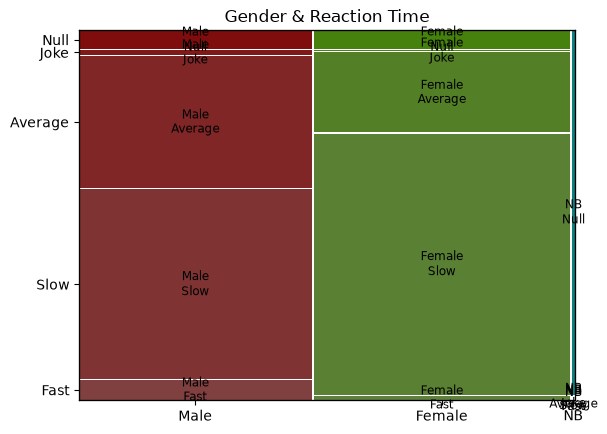

In [13]:
mosaic(data2, ["Gender", "Reaciton_time"], title="Gender & Reaction Time")
matplotlib.pyplot.show()

In [14]:
pd.crosstab(index=t2_g2, columns=t2_r2, margins=True)

Reaction_time,Average,Fast,Joke,Null,Slow,All
Gender,,,,,,
Female,57,3,1,13,186,260
Male,86,13,3,12,123,237
NB,0,0,0,3,0,3
All,143,16,4,28,309,500


# Conclusion
### There does seem to be a coorilation between Gender and Reaction time. Usually, it seems that females in this dataset are slower than males in this dataset.